# Task 1: Potential Problems in Linear Regression

This notebook explores three common problems that can arise when fitting a linear regression model: non-constant variance of error terms, collinearity, and outliers. For each issue, I used generative AI to create plot examples that illustrate these problems.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

np.random.seed(42)

---
## Issue 1: Non-Constant Variance of Error Terms

One assumption of linear regression is that the error terms have constant variance, meaning the spread of the residuals should look roughly the same across all fitted values. When the regression does not follow the assumption, the errors are called heteroscedastic, meaning some parts of the data have much more scatter than others. This is a problem because it makes the standard errors untrustworthy, which makes confidence intervals and hypothesis tests unreliable. The easiest way to spot it is to plot residuals against fitted values and look for a funnel or fan shape. One way to fix the issue is to transform the response variable, for example, taking the log, which can pull in the high-variance region and stabilize the spread.


**Question I investigated**: Does fixing heteroscedasticity change the coefficient estimates or just the standard errors?

Answer: By applying a transformation like log to the response variable changes both. The model is now predicting log(Y) instead of Y, so the coefficients have a different interpretation and different values. However, if you use weighted least squares instead, the main impact would be on the standard errors rather than the coefficient values.

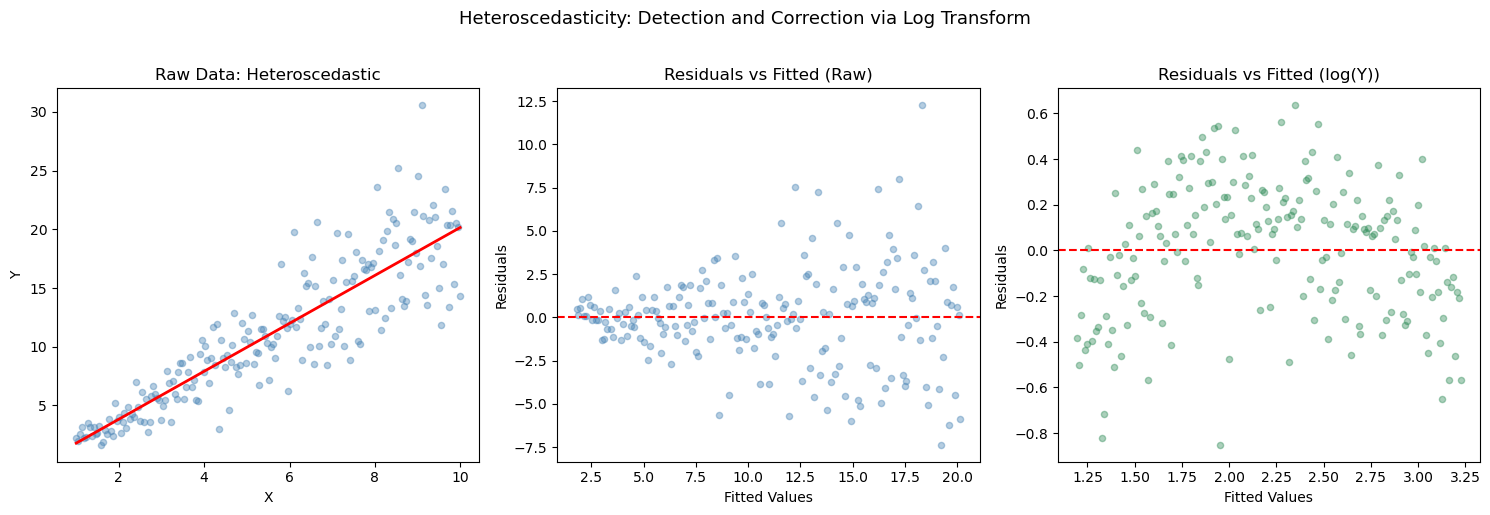

In [3]:
# Generate heteroscedastic data
n = 200
x = np.linspace(1, 10, n)
# Variance grows with x (fan shape)
y_het = 2 * x + np.random.normal(0, 0.5 * x, n)
y_log = np.log(y_het)  # log-transform to address it

# Fit models
X = x.reshape(-1, 1)
model_het = LinearRegression().fit(X, y_het)
fitted_het = model_het.predict(X)
resid_het = y_het - fitted_het

model_log = LinearRegression().fit(X, y_log)
fitted_log = model_log.predict(X)
resid_log = y_log - fitted_log

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Raw scatter
axes[0].scatter(x, y_het, alpha=0.4, color='steelblue', s=20)
axes[0].plot(x, fitted_het, color='red', linewidth=2)
axes[0].set_title('Raw Data: Heteroscedastic')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')

# Residuals vs fitted — raw
axes[1].scatter(fitted_het, resid_het, alpha=0.4, color='steelblue', s=20)
axes[1].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[1].set_title('Residuals vs Fitted (Raw)')
axes[1].set_xlabel('Fitted Values')
axes[1].set_ylabel('Residuals')

# Residuals vs fitted — log transformed
axes[2].scatter(fitted_log, resid_log, alpha=0.4, color='seagreen', s=20)
axes[2].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[2].set_title('Residuals vs Fitted (log(Y))')
axes[2].set_xlabel('Fitted Values')
axes[2].set_ylabel('Residuals')

plt.suptitle('Heteroscedasticity: Detection and Correction via Log Transform', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Figure caption:** The first plot shows the raw data with a clear fan shape, variance increases with X. The second plot confirms heteroscedasticity: residuals fan out as fitted values grow, violating the constant-variance assumption. The third plot shows that after applying a log transformation to Y, the residuals spread evenly across the range of fitted values, indicating the variance has been stabilized.

---
## Issue 2: Collinearity

The Collinearity issue occurs when two or more predictors in a regression model are highly correlated with one another. When this happens, it becomes difficult for the model to separate out the individual effect of each predictor, the coefficient estimates become unstable and their standard errors inflate, making it hard to determine which predictors truly matter. Collinearity can be detected by looking at the correlation matrix between predictors, or by computing the Variance Inflation Factor (VIF), where a VIF above 5–10 signals a collinearity problem. There are two main fixes to the issue: drop one of the collinear predictors, or combine them into a single variable, for example by averaging the two together.

**Question I investigated:** Does collinearity affect prediction, or only inference?

Answer: Collinearity primarily affects inference (standard errors, hypothesis tests, interpretability of individual coefficients), not necessarily prediction. If the collinear structure in training data is also present in test data, predictions can still be accurate. However, if a model trained on collinear data is applied to new data where the correlation between those predictors has broken down, predictions degrade significantly, the instability in coefficient estimates propagates to predictions in those regions.

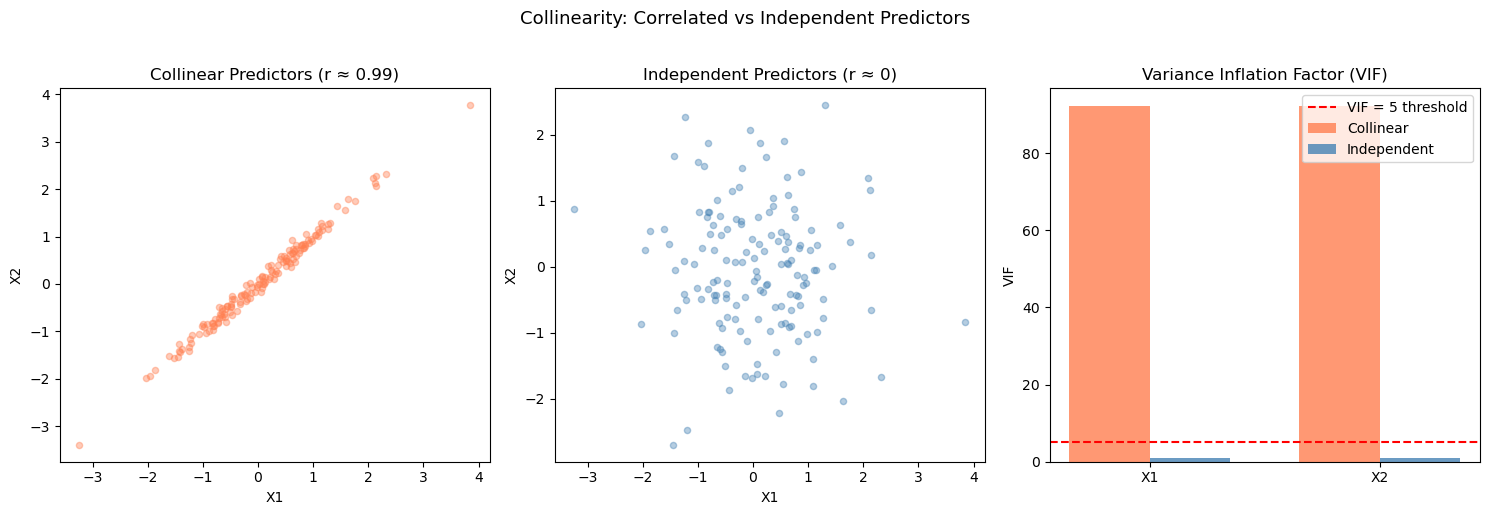

VIF (collinear case):    X1=92.2, X2=92.2
VIF (independent case):  X1=1.0, X2=1.0


In [4]:
# Generate collinear data
n = 150
x1 = np.random.normal(0, 1, n)
x2_collinear = x1 + np.random.normal(0, 0.1, n)  # x2 ≈ x1
x2_independent = np.random.normal(0, 1, n)        # x2 independent of x1
y = 2 * x1 + 1.5 * x2_collinear + np.random.normal(0, 0.5, n)

# VIF for collinear case
X_col = np.column_stack([x1, x2_collinear])
X_col_const = sm.add_constant(X_col)
vif_col = [variance_inflation_factor(X_col_const, i) for i in range(1, 3)]

# VIF for independent case
X_ind = np.column_stack([x1, x2_independent])
X_ind_const = sm.add_constant(X_ind)
vif_ind = [variance_inflation_factor(X_ind_const, i) for i in range(1, 3)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Scatter: collinear predictors
axes[0].scatter(x1, x2_collinear, alpha=0.4, color='coral', s=20)
axes[0].set_title('Collinear Predictors (r ≈ 0.99)')
axes[0].set_xlabel('X1')
axes[0].set_ylabel('X2')

# Scatter: independent predictors
axes[1].scatter(x1, x2_independent, alpha=0.4, color='steelblue', s=20)
axes[1].set_title('Independent Predictors (r ≈ 0)')
axes[1].set_xlabel('X1')
axes[1].set_ylabel('X2')

# VIF bar chart comparison
labels = ['X1', 'X2']
x_pos = np.arange(len(labels))
width = 0.35
axes[2].bar(x_pos - width/2, vif_col, width, label='Collinear', color='coral', alpha=0.8)
axes[2].bar(x_pos + width/2, vif_ind, width, label='Independent', color='steelblue', alpha=0.8)
axes[2].axhline(5, color='red', linestyle='--', linewidth=1.5, label='VIF = 5 threshold')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(labels)
axes[2].set_ylabel('VIF')
axes[2].set_title('Variance Inflation Factor (VIF)')
axes[2].legend()

plt.suptitle('Collinearity: Correlated vs Independent Predictors', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"VIF (collinear case):    X1={vif_col[0]:.1f}, X2={vif_col[1]:.1f}")
print(f"VIF (independent case):  X1={vif_ind[0]:.1f}, X2={vif_ind[1]:.1f}")

**Figure caption:** The first plot shows two highly collinear predictors (r ~ 0.99), where nearly all points fall along a line, meaning the two variables carry almost identical information. The second plot shows two independent predictors with no discernible pattern. The third plot compares VIF values: when predictors are collinear, VIF is extremely high (far exceeding the threshold of 5), indicating the variance of each coefficient estimate is massively inflated, making individual coefficient interpretation unreliable.

---
## Issue 3: Outliers

An outlier is an observation whose response value is unusual given its predictor values, meaning it has a large residual, they matter because they can distort the fitted regression line, inflate the residual standard error, and make confidence intervals wider and the R^2 lower than they would be otherwise. Outliers are easiest to spot visually using residual plots, or more formally through studentized residuals, observations with a value above 3 or below -3 are flagged as potential outliers. What we do about them depends on context: if the outlier is a data entry error it should be corrected or removed, but if it's a genuine observation it may be worth investigating separately rather than just deleting it.

**Question I investigated:** Where does the cutoff of 3 for studentized residuals come from?

Answer: It comes from the fact that in a normal distribution, roughly 99.7% of values fall within 3 standard deviations of the mean. So a studentized residual beyond 3 is something you'd rarely see by chance if the model were correct, making it a reasonable flag for further investigation. But still considered a guideline not a rule, and in large datasets you'd expect a few observations to exceed it just by chance.

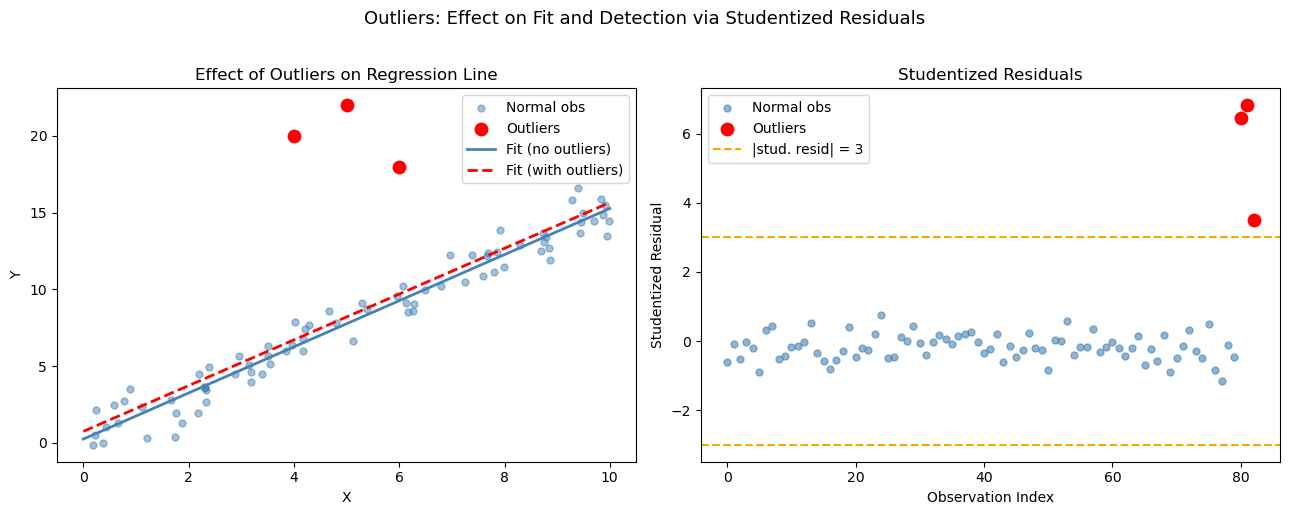

In [5]:
# Generate data with and without outliers
n = 80
x_base = np.random.uniform(0, 10, n)
y_base = 1.5 * x_base + np.random.normal(0, 1, n)

# Add 3 outliers (unusual y given x)
x_out = np.append(x_base, [4, 5, 6])
y_out = np.append(y_base, [20, 22, 18])  # way above the trend

# Fit both models
model_clean = LinearRegression().fit(x_base.reshape(-1,1), y_base)
model_outlier = LinearRegression().fit(x_out.reshape(-1,1), y_out)

x_line = np.linspace(0, 10, 100)
y_clean_line = model_clean.predict(x_line.reshape(-1,1))
y_outlier_line = model_outlier.predict(x_line.reshape(-1,1))

# Studentized residuals for outlier model
X_sm = sm.add_constant(x_out)
ols_model = sm.OLS(y_out, X_sm).fit()
influence = ols_model.get_influence()
studentized_resid = influence.resid_studentized_external

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: effect of outliers on fit
axes[0].scatter(x_base, y_base, alpha=0.5, color='steelblue', s=25, label='Normal obs')
axes[0].scatter([4,5,6], [20,22,18], color='red', s=80, zorder=5, label='Outliers')
axes[0].plot(x_line, y_clean_line, color='steelblue', linewidth=2, label='Fit (no outliers)')
axes[0].plot(x_line, y_outlier_line, color='red', linewidth=2, linestyle='--', label='Fit (with outliers)')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].set_title('Effect of Outliers on Regression Line')
axes[0].legend()

# Studentized residuals
obs_idx = np.arange(len(x_out))
axes[1].scatter(obs_idx[:-3], studentized_resid[:-3], color='steelblue', alpha=0.6, s=25, label='Normal obs')
axes[1].scatter(obs_idx[-3:], studentized_resid[-3:], color='red', s=80, zorder=5, label='Outliers')
axes[1].axhline(3, color='orange', linestyle='--', linewidth=1.5, label='|stud. resid| = 3')
axes[1].axhline(-3, color='orange', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Observation Index')
axes[1].set_ylabel('Studentized Residual')
axes[1].set_title('Studentized Residuals')
axes[1].legend()

plt.suptitle('Outliers: Effect on Fit and Detection via Studentized Residuals', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Figure caption:** The first plot shows how three outliers (high Y values for moderate X) pull the regression line upward compared to the clean fit, inflating the intercept and distorting the slope. The second plot studentized residuals for all observations, the three outliers are flagged above the 3 threshold, making them easy to identify formally.

---
## Generative AI Reflection

I used Claude to generate the Python code for the three plots in this task. My prompts followed the assignment instructions and included some background on each issue, for example: "write Python code that generates synthetic data clearly illustrating the linear regression issue of collinearity, produces plots making the issue visually clear, and where applicable shows how to address it". The code worked on the first attempt for all three issues, but I made a few additional iterations to make it cleaner, and more consistent with the examples in the book, around 2 to 3 iterations per plot. I had to delete some unnecessary libraries that it loaded, but never used